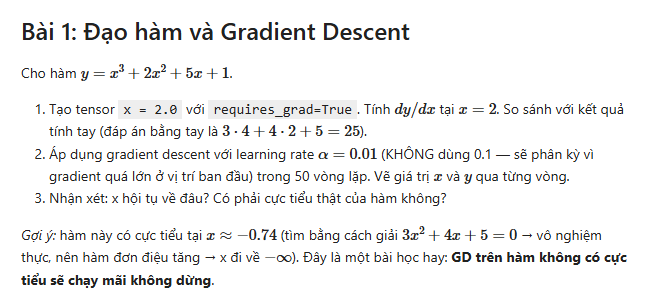

In [10]:
import torch

x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x**2 + 5*x + 1

y.backward()

print(f"Giá trị dy/dx tại x=2 tính bằng PyTorch: {x.grad.item()}")
print(f"So sánh với kết quả tính tay (25): {'Khớp' if x.grad.item() == 25 else 'Không khớp'}")

Giá trị dy/dx tại x=2 tính bằng PyTorch: 25.0
So sánh với kết quả tính tay (25): Khớp


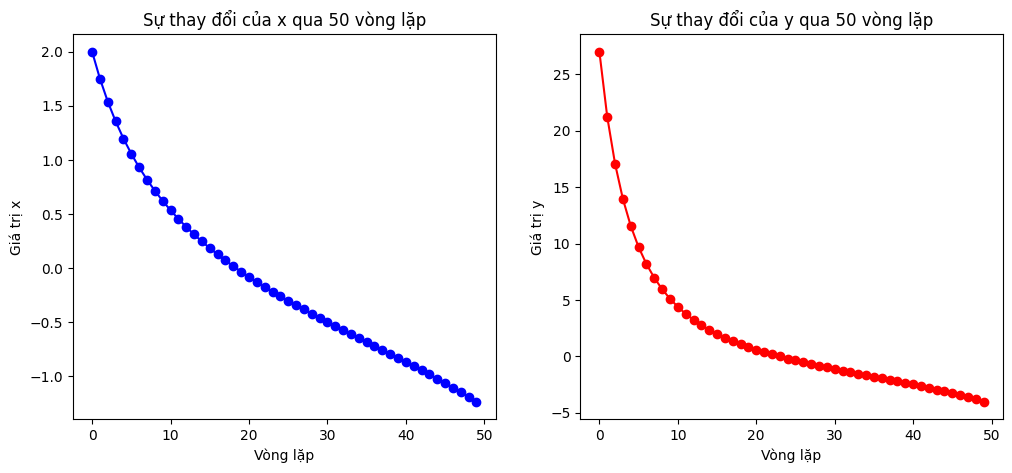

In [11]:
import matplotlib.pyplot as plt

x_gd = torch.tensor(2.0, requires_grad=True)
lr = 0.01
epochs = 50

history_x = []
history_y = []

for i in range(epochs):
    y_curr = x_gd**3 + 2*x_gd**2 + 5*x_gd + 1

    history_x.append(x_gd.item())
    history_y.append(y_curr.item())

    y_curr.backward()

    with torch.no_grad():
        x_gd -= lr * x_gd.grad
    x_gd.grad.zero_()

# Vẽ đồ thị kết quả
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_x, 'b-o')
plt.title('Sự thay đổi của x qua 50 vòng lặp')
plt.xlabel('Vòng lặp'); plt.ylabel('Giá trị x')

plt.subplot(1, 2, 2)
plt.plot(history_y, 'r-o')
plt.title('Sự thay đổi của y qua 50 vòng lặp')
plt.xlabel('Vòng lặp'); plt.ylabel('Giá trị y')
plt.show()

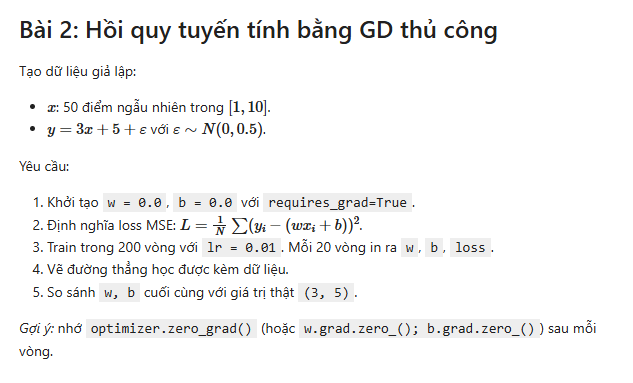

In [12]:
import torch
import matplotlib.pyplot as plt

# Tạo dữ liệu x: 50 điểm trong khoảng [1, 10]
# torch.rand(50) tạo ra số trong [0, 1), ta cần biến đổi về [1, 10]
x = 1 + 9 * torch.rand(50)

# Tạo dữ liệu y với nhiễu epsilon ~ N(0, 0.5)
true_w, true_b = 3.0, 5.0
epsilon = 0.5 * torch.randn(50)
y = true_w * x + true_b + epsilon

# 1. Khởi tạo w, b = 0.0
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

In [13]:
lr = 0.01
epochs = 200

print(f"{'Epoch':<10} | {'w':<10} | {'b':<10} | {'Loss':<10}")
print("-" * 45)

for epoch in range(1, epochs + 1):
    # Dự đoán: y_pred = w*x + b
    y_pred = w * x + b

    # 2. Định nghĩa loss MSE: L = 1/N * sum(y_i - y_pred)^2
    loss = torch.mean((y - y_pred)**2)

    # Tính gradient
    loss.backward()

    # 3. Cập nhật w, b và in kết quả mỗi 20 vòng
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        # Quan trọng: Xóa gradient sau mỗi vòng lặp
        w.grad.zero_()
        b.grad.zero_()

    if epoch % 20 == 0:
        print(f"{epoch:<10} | {w.item():.4f} | {b.item():.4f} | {loss.item():.4f}")

Epoch      | w          | b          | Loss      
---------------------------------------------
20         | 3.6524 | 0.8706 | 3.4674
40         | 3.6090 | 1.1539 | 3.0546
60         | 3.5684 | 1.4182 | 2.6951
80         | 3.5306 | 1.6648 | 2.3821
100        | 3.4954 | 1.8949 | 2.1096
120        | 3.4624 | 2.1097 | 1.8722
140        | 3.4317 | 2.3100 | 1.6656
160        | 3.4030 | 2.4970 | 1.4857
180        | 3.3763 | 2.6715 | 1.3290
200        | 3.3513 | 2.8343 | 1.1926


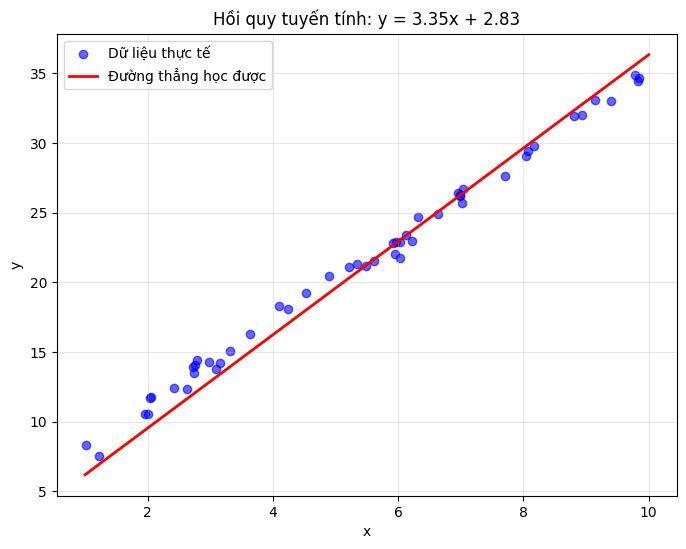


Kết quả cuối cùng:
w học được: 3.3513 (Giá trị thật: 3.0)
b học được: 2.8343 (Giá trị thật: 5.0)


In [14]:
# 4. Vẽ đường thẳng học được
plt.figure(figsize=(8, 6))
plt.scatter(x.numpy(), y.numpy(), label='Dữ liệu thực tế', color='blue', alpha=0.6)

# Tạo đường thẳng dự đoán dựa trên w và b cuối cùng
x_range = torch.linspace(1, 10, 100)
y_range = w.item() * x_range + b.item()

plt.plot(x_range.numpy(), y_range.numpy(), color='red', linewidth=2, label='Đường thẳng học được')
plt.title(f'Hồi quy tuyến tính: y = {w.item():.2f}x + {b.item():.2f}')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 5. So sánh với giá trị thật (3, 5)
print(f"\nKết quả cuối cùng:")
print(f"w học được: {w.item():.4f} (Giá trị thật: 3.0)")
print(f"b học được: {b.item():.4f} (Giá trị thật: 5.0)")

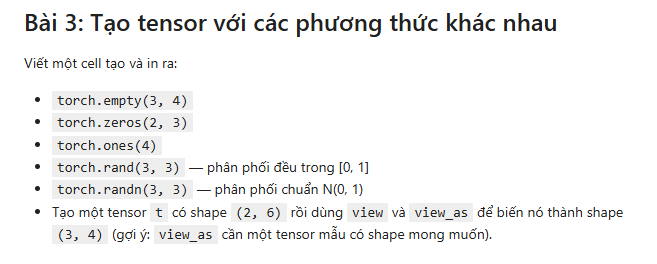

In [15]:
import torch

# 1. Tạo và in các tensor cơ bản
print("--- Tensor cơ bản ---")
print("Empty (3,4):\n", torch.empty(3, 4))
print("Zeros (2,3):\n", torch.zeros(2, 3))
print("Ones (4):\n", torch.ones(4))
print("Rand (3,3) - Phân phối đều [0,1]:\n", torch.rand(3, 3))
print("Randn (3,3) - Phân phối chuẩn N(0,1):\n", torch.randn(3, 3))

# 2. Reshape tensor
print("\n--- Reshape Tensor ---")
t = torch.randn(2, 6)
print("Shape ban đầu:", t.shape)

# Dùng view để biến thành (3, 4)
t_view = t.view(3, 4)
print("Shape sau khi dùng view(3, 4):", t_view.shape)

# Dùng view_as với một mẫu có shape mong muốn
target = torch.empty(3, 4)
t_view_as = t.view_as(target)
print("Shape sau khi dùng view_as(target):", t_view_as.shape)

--- Tensor cơ bản ---
Empty (3,4):
 tensor([[1.5766e-19, 1.0256e-08, 6.5631e-07, 3.1300e+12],
        [2.7096e-09, 4.2195e-08, 1.6970e-07, 1.2469e+16],
        [2.1707e-18, 7.0952e+22, 1.7748e+28, 1.8176e+31]])
Zeros (2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
Ones (4):
 tensor([1., 1., 1., 1.])
Rand (3,3) - Phân phối đều [0,1]:
 tensor([[0.0323, 0.6731, 0.9389],
        [0.9313, 0.9174, 0.6331],
        [0.5660, 0.9810, 0.4562]])
Randn (3,3) - Phân phối chuẩn N(0,1):
 tensor([[ 0.4746, -0.7006, -0.9801],
        [-0.4052, -0.0462,  1.7485],
        [ 0.8575,  2.0529, -0.0057]])

--- Reshape Tensor ---
Shape ban đầu: torch.Size([2, 6])
Shape sau khi dùng view(3, 4): torch.Size([3, 4])
Shape sau khi dùng view_as(target): torch.Size([3, 4])


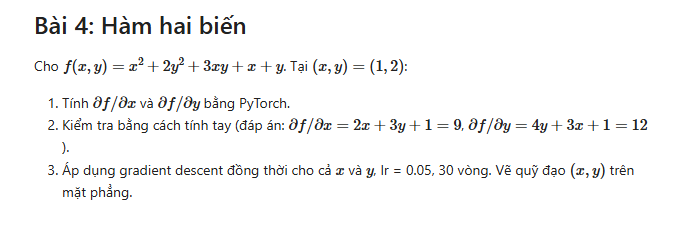

In [16]:

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

f = x**2 + 2*y**2 + 3*x*y + x + y

f.backward()

print(f"Đạo hàm riêng theo x (df/dx): {x.grad.item()} (Tính tay: 9)")
print(f"Đạo hàm riêng theo y (df/dy): {y.grad.item()} (Tính tay: 12)")

Đạo hàm riêng theo x (df/dx): 9.0 (Tính tay: 9)
Đạo hàm riêng theo y (df/dy): 12.0 (Tính tay: 12)


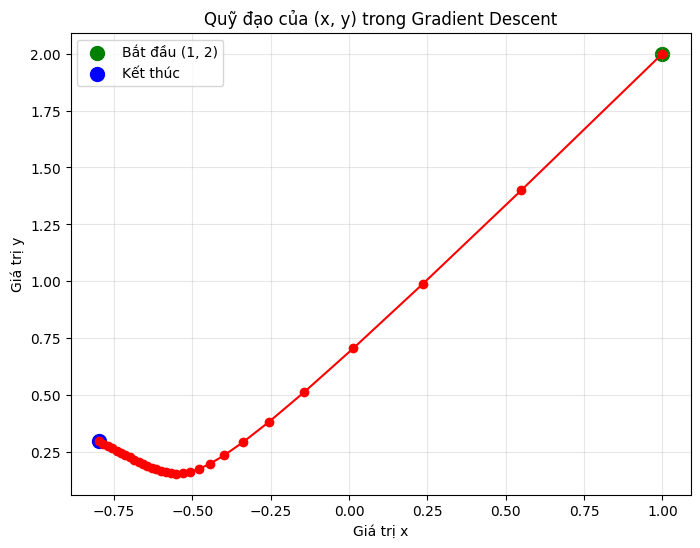

In [17]:
import matplotlib.pyplot as plt

x_gd = torch.tensor(1.0, requires_grad=True)
y_gd = torch.tensor(2.0, requires_grad=True)
lr = 0.05
epochs = 30

history_x = []
history_y = []

for i in range(epochs):
    history_x.append(x_gd.item())
    history_y.append(y_gd.item())
    f_curr = x_gd**2 + 2*y_gd**2 + 3*x_gd*y_gd + x_gd + y_gd
    f_curr.backward()
    with torch.no_grad():
        x_gd -= lr * x_gd.grad
        y_gd -= lr * y_gd.grad
        x_gd.grad.zero_()
        y_gd.grad.zero_()
plt.figure(figsize=(8, 6))
plt.plot(history_x, history_y, 'ro-')
plt.scatter(history_x[0], history_y[0], color='green', label='Bắt đầu (1, 2)', s=100)
plt.scatter(history_x[-1], history_y[-1], color='blue', label='Kết thúc', s=100)

plt.title('Quỹ đạo của (x, y) trong Gradient Descent')
plt.xlabel('Giá trị x')
plt.ylabel('Giá trị y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()